# gradient-boosted tree

In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')
train, test = dataset.build_train_test()

/home/matt/repos/nitor-comp/dataengineers.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df[f'{col}_ramp_{diff}h'] = (


In [4]:
exclude = ['id', 'target', 'delivery_start', 'market', 'market_int', 'timestamp_int', 'day_of_year', 'dayofweek', 'hour']

In [5]:
features = [c for c in train.columns if c not in exclude]

In [6]:
from models import XGB

In [7]:
xg = XGB(features)

In [8]:
xg.fit(train, test)

[0]	validation_0-rmse:2.22245	validation_1-rmse:2.42793
[100]	validation_0-rmse:1.66184	validation_1-rmse:1.93255
[200]	validation_0-rmse:1.48323	validation_1-rmse:1.84514
[300]	validation_0-rmse:1.39615	validation_1-rmse:1.82993
[400]	validation_0-rmse:1.33981	validation_1-rmse:1.82680
[500]	validation_0-rmse:1.30267	validation_1-rmse:1.82606
[572]	validation_0-rmse:1.28019	validation_1-rmse:1.82799


In [9]:
y_vals = xg.predict(test)

/home/matt/repos/nitor-comp/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [13:14:11] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [10]:
from utils import rmse

In [11]:
rmse(test['target'], y_vals)

np.float64(49.307254499853045)

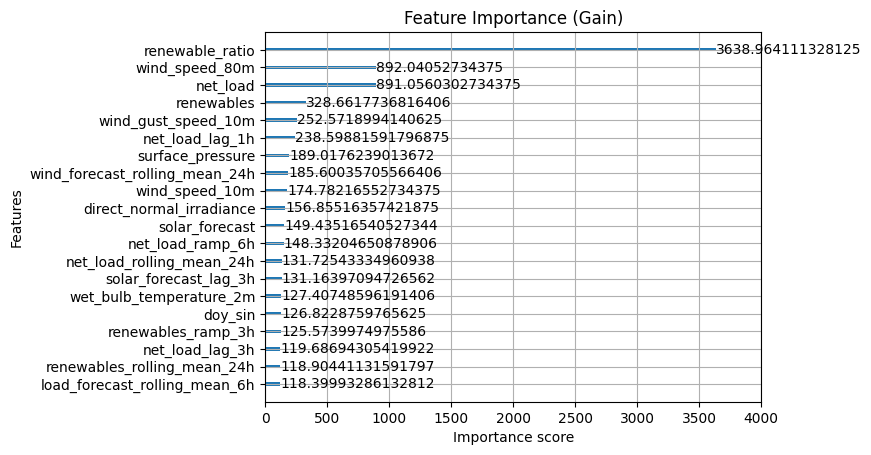

In [12]:
xg.stats()